In [1]:
import torch
import geospaNN
import numpy as np
import time
import pandas as pd
import seaborn as sns
import scipy
import lhsmdu
import random

import matplotlib
import matplotlib.pyplot as plt

path = '../data/Output/'

R callback write-console: Loading required package: BRISC
  
R callback write-console: Loading required package: RANN
  
R callback write-console: Loading required package: parallel
  
R callback write-console: Loading required package: rdist
  
R callback write-console: Loading required package: matrixStats
  
R callback write-console: Loading required package: pbapply
  
R callback write-console: The ordering of inputs x (covariates) and y (response) in BRISC_estimation has been changed BRISC 1.0.0 onwards.
  Please check the new documentation with ?BRISC_estimation.
  


R package: BRISC installed


/Users/zhanwentao/miniforge3/envs/Test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def RMSE(x,y):
    x = x.reshape(-1)
    y = y.reshape(-1)
    n = x.shape[0]
    return(np.sqrt(np.sum(np.square(x-y))/n))

def f5(X): return (10 * np.sin(np.pi * X[:, 0] * X[:, 1]) + 20 * (X[:, 2] - 0.5) ** 2 + 10 * X[:, 3] + 5 * X[:, 4]) / 6

sigma = 1
phi = 3
Lambda = 0.01
theta = torch.tensor([sigma, phi / np.sqrt(2), Lambda])

p = 5;
funXY = f5

n = 1000
nn = 20
batch_size = 50

N = 1000
n_small = int(N / 100)
np.random.seed(2021)
X_MISE = np.array(lhsmdu.sample(p, n_small).reshape((n_small, p)))
for i in range(99):
    temp = np.array(lhsmdu.sample(p, n_small).reshape((n_small, p)))
    X_MISE = np.concatenate((X_MISE, temp))

X_MISE_torch = torch.from_numpy(X_MISE).float()

In [3]:
torch.manual_seed(2025)
X, Y, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, 10])

X, Y, coord, _ = geospaNN.spatial_order(X, Y, coord, method='max-min')
data = geospaNN.make_graph(X, Y, coord, nn)

torch.manual_seed(2025)
np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn,
                                                      test_proportion=0.2)

/var/folders/lv/q9wzh97j5253zdyp95xsfvgw0000gn/T/ipykernel_11003/3891925826.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def f5(X): return (10 * np.sin(np.pi * X[:, 0] * X[:, 1]) + 20 * (X[:, 2] - 0.5) ** 2 + 10 * X[:, 3] + 5 * X[:, 4]) / 6


In [4]:
data_train.x

tensor([[0.9175, 0.3773, 0.2118, 0.0680, 0.0179],
        [0.7936, 0.4667, 0.4675, 0.1269, 0.9975],
        [0.0682, 0.5255, 0.5604, 0.5863, 0.5488],
        ...,
        [0.6062, 0.9212, 0.3833, 0.6155, 0.9018],
        [0.7543, 0.4319, 0.5977, 0.2825, 0.6047],
        [0.1806, 0.4579, 0.9529, 0.5656, 0.7100]])

In [5]:
torch.manual_seed(2025)
np.random.seed(0)
data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn,
                                                      test_proportion=0.2)
data_train.x

tensor([[0.9175, 0.3773, 0.2118, 0.0680, 0.0179],
        [0.7936, 0.4667, 0.4675, 0.1269, 0.9975],
        [0.0682, 0.5255, 0.5604, 0.5863, 0.5488],
        ...,
        [0.6062, 0.9212, 0.3833, 0.6155, 0.9018],
        [0.7543, 0.4319, 0.5977, 0.2825, 0.6047],
        [0.1806, 0.4579, 0.9529, 0.5656, 0.7100]])

In [6]:
import utils_pygam

In [7]:
torch.manual_seed(2024)
mlp_nn = torch.nn.Sequential(
    torch.nn.Linear(p, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 1)
)
nn_model = geospaNN.nn_train(mlp_nn, lr=0.01, min_delta=0.001)
training_log = nn_model.train(data_train, data_val, data_test, seed = 2024)
theta0 = geospaNN.theta_update(mlp_nn(data_train.x).squeeze() - data_train.y,data_train.pos, neighbor_size=20)

INFO: Early stopping
End at epoch68
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.90340745 2.85536437 0.04691024]


In [8]:
Est_NN = mlp_nn(X_MISE_torch).detach().numpy()
RMSE(Est_NN, funXY(X_MISE))

np.float64(0.39721508737419925)

In [9]:
torch.manual_seed(2024)
mlp_nngls = torch.nn.Sequential(
    torch.nn.Linear(p, 50),
    torch.nn.ReLU(),
    torch.nn.Linear(50, 20),
    torch.nn.ReLU(),
    torch.nn.Linear(20, 1)
)
model_nngls = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nngls, theta=torch.tensor(theta0))
nngls_model = geospaNN.nngls_train(model_nngls, lr=0.02, min_delta=0.001)
training_log = nngls_model.train(data_train, data_val, data_test,
                                 Update_init=10, Update_step=5, seed = 2024)

---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.9381478  2.83101983 0.02558928]
to
[0.9381478  2.83101983 0.02558928]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.91828618 2.8080793  0.04000631]
to
[0.91828618 2.8080793  0.04000631]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[9.52449664e-01 2.74792770e+00 2.43780456e-03]
to
[9.52449664e-01 2.74792770e+00 2.43780456e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[9.32178869e-01 2.70865742e+00 1.00000000e-03]
to
[9.32178869e-01 2.70865742e+00 1.00000000e-03]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[9.31923437e-01 2.64651324e+00 1.00000000e-03]
to
[9.31923437e-01 2.64651324e+00 1.00000000e-03]
INFO: Early stopping
End at epoch37


In [10]:
Est_NNGLS = mlp_nngls(X_MISE_torch).detach().numpy()
RMSE(Est_NNGLS, funXY(X_MISE))

np.float64(0.24671619710539494)

In [11]:
torch.manual_seed(2024)
np.random.seed(2024)
X_train = data_train.x.detach().numpy()
Y_train = data_train.y.detach().numpy()
gam = utils_pygam.my_LinearGAM()
gam.fit(X_train, Y_train)
Xspline = gam._modelmat(X_train)
gam.my_fit(X_train, Xspline, Y_train)

my_LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + intercept, tol=0.0001, 
   verbose=False)

In [12]:
Est_GAM = gam.predict(X_MISE)
RMSE(Est_GAM, funXY(X_MISE))

np.float64(0.3790613980433678)

In [13]:
torch.manual_seed(2024)
np.random.seed(2024)
X_train = data_train.x.detach().numpy()
Y_train = data_train.y.detach().numpy()
gam = utils_pygam.my_LinearGAM()
gam.fit(X_train, Y_train)
Xspline = gam._modelmat(X_train)
I_B_GAM, F_GAM = geospaNN.make_bf(data_train.pos, theta0, nn)
I_B_GAM = I_B_GAM.to_dense()
F_GAM = F_GAM.detach().numpy()
FI_B_GAM = (I_B_GAM.T * np.sqrt(np.reciprocal(F_GAM))).T
gam.my_fit(X_train,
           scipy.sparse.csr_matrix(np.matmul(FI_B_GAM, Xspline.todense())),
           np.array(np.matmul(FI_B_GAM, Y_train)))

my_LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, 
   terms=s(0) + s(1) + s(2) + s(3) + s(4) + intercept, tol=0.0001, 
   verbose=False)

In [14]:
Est_GAMGLS = gam.predict(X_MISE)
RMSE(Est_GAMGLS, funXY(X_MISE))

np.float64(0.35384695401104277)

In [15]:
rho_vec = []
MSE_GAMGLS = []
MSE_NNGLS = []
for rho in list(np.array(range(21))/20):
    print(rho)
    def f5(X): return rho * (10 * np.sin(np.pi * X[:, 0] * X[:, 1]))/3 + \
                      (1-rho)*(20 * (X[:, 2] - 0.5) ** 2 + 10 * X[:, 3] + 5 * X[:,4]) / 3

    funXY = f5
    torch.manual_seed(2024)
    X, Y, coord, cov, corerr = geospaNN.Simulation(n, p, nn, funXY, theta, range=[0, 10])
    random.seed(2024)
    X, Y, coord, _ = geospaNN.spatial_order(X, Y, coord, method='max-min')
    data = geospaNN.make_graph(X, Y, coord, nn)
    torch.manual_seed(2024)
    np.random.seed(0)
    data_train, data_val, data_test = geospaNN.split_data(X, Y, coord, neighbor_size=nn,
                                                          test_proportion=0.2)
    torch.manual_seed(2024)
    mlp_nngls = torch.nn.Sequential(
        torch.nn.Linear(p, 50),
        torch.nn.ReLU(),
        torch.nn.Linear(50, 20),
        torch.nn.ReLU(),
        torch.nn.Linear(20, 1)
    )
    model_nngls = geospaNN.nngls(p=p, neighbor_size=nn, coord_dimensions=2, mlp=mlp_nngls, theta=torch.tensor(theta0))
    nngls_model = geospaNN.nngls_train(model_nngls, lr=0.02, min_delta=0.001)
    training_log = nngls_model.train(data_train, data_val, data_test,
                                     Update_init=10, Update_step=5, seed = 2024)
    Est_NNGLS = mlp_nngls(X_MISE_torch).detach().numpy()
    MSE_NNGLS.append(RMSE(Est_NNGLS, funXY(X_MISE)))
    
    torch.manual_seed(2024)
    np.random.seed(2024)
    X_train = data_train.x.detach().numpy()
    Y_train = data_train.y.detach().numpy()
    gam = utils_pygam.my_LinearGAM()
    gam.fit(X_train, Y_train)
    Xspline = gam._modelmat(X_train)
    I_B_GAM, F_GAM = geospaNN.make_bf(data_train.pos, theta0, nn)
    I_B_GAM = I_B_GAM.to_dense()
    F_GAM = F_GAM.detach().numpy()
    FI_B_GAM = (I_B_GAM.T * np.sqrt(np.reciprocal(F_GAM))).T
    gam.my_fit(X_train,
               scipy.sparse.csr_matrix(np.matmul(FI_B_GAM, Xspline.todense())),
               np.array(np.matmul(FI_B_GAM, Y_train)))
    
    Est_GAMGLS = gam.predict(X_MISE)
    MSE_GAMGLS.append(RMSE(Est_GAMGLS, funXY(X_MISE)))
    rho_vec.append(rho) 

0.0
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.8317051  2.68177351 0.0362144 ]
to
[0.8317051  2.68177351 0.0362144 ]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.85112797 2.8608756  0.02814126]
to
[0.85112797 2.8608756  0.02814126]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


...

Theta estimated as
[0.78021072 2.71896381 0.19801605]
to
[0.78021072 2.71896381 0.19801605]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.774226   2.7356716  0.10311868]
to
[0.774226   2.7356716  0.10311868]
---------------------------------------- 
	Ordering Coordinates 
----------------------------------------
	Model description
----------------------------------------
BRISC model fit with 600 observations.

Number of covariates 1 (including intercept if specified).

Using the exponential spatial correlation model.

Using 15 nearest neighbors.


Source compiled with OpenMP support and model fit using 1 thread(s).
----------------------------------------
	Building neighbor index
----------------------------------------
	Performing optimization
----------------------------------------
	Processing optimizers
----------------------------------------


  
   
Please check the new documentation with ?BRISC_estimation.
  


Theta estimated as
[0.78622917 2.75230042 0.05248574]
to
[0.78622917 2.75230042 0.05248574]
INFO: Early stopping
End at epoch29


In [16]:
df_MSE = pd.DataFrame(
    {'GAMGLS': np.array(MSE_GAMGLS), 'NNGLS': np.array(MSE_NNGLS), 'rho': np.array(rho_vec)})

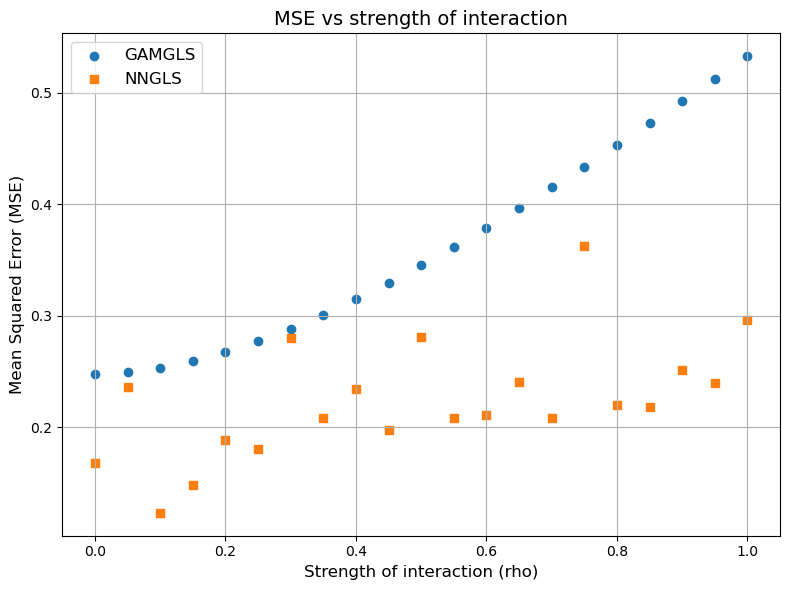

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot using Matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(df_MSE['rho'], df_MSE['GAMGLS'], label='GAMGLS', marker='o')
plt.scatter(df_MSE['rho'], df_MSE['NNGLS'], label='NNGLS', marker='s')

# Add titles and labels
plt.title('MSE vs strength of interaction', fontsize=14)
plt.xlabel('Strength of interaction (rho)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.savefig(path + "GAM.png")

<Figure size 640x480 with 0 Axes>

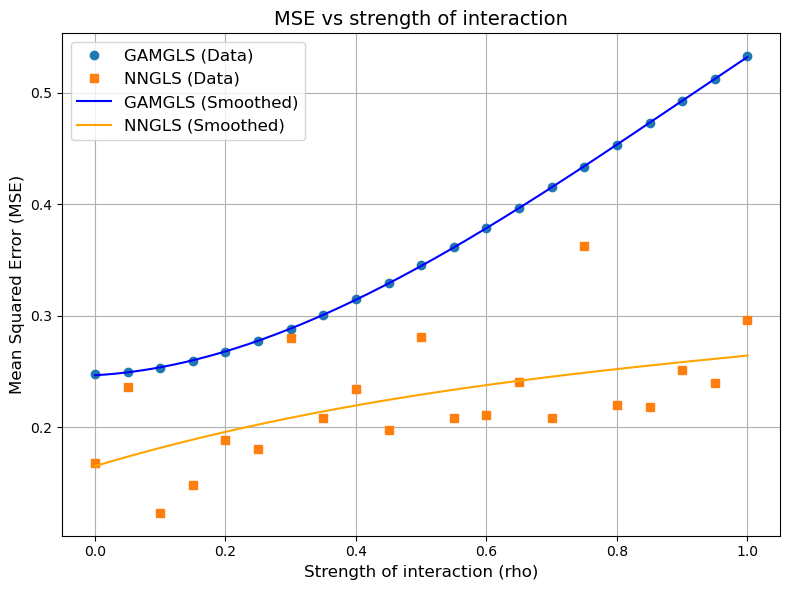

In [18]:
degree = 3  # Degree of the polynomial
rho_smooth = np.linspace(df_MSE['rho'].min(), df_MSE['rho'].max(), 200)

# Fit polynomials for GAMGLS and NNGLS
gamgls_fit = np.polyfit(df_MSE['rho'], df_MSE['GAMGLS'], degree)
nngls_fit = np.polyfit(df_MSE['rho'], df_MSE['NNGLS'], degree)

# Evaluate the polynomial on a smooth grid
gamgls_smooth = np.polyval(gamgls_fit, rho_smooth)
nngls_smooth = np.polyval(nngls_fit, rho_smooth)

# Plot using Matplotlib
plt.clf()
plt.figure(figsize=(8, 6))

# Original points
plt.plot(df_MSE['rho'], df_MSE['GAMGLS'], label='GAMGLS (Data)', marker='o', linestyle='none')
plt.plot(df_MSE['rho'], df_MSE['NNGLS'], label='NNGLS (Data)', marker='s', linestyle='none')

# Smoothed curves
plt.plot(rho_smooth, gamgls_smooth, label='GAMGLS (Smoothed)', color='blue', linestyle='-', linewidth=1.5)
plt.plot(rho_smooth, nngls_smooth, label='NNGLS (Smoothed)', color='orange', linestyle='-', linewidth=1.5)
# Add titles and labels
plt.title('MSE vs strength of interaction', fontsize=14)
plt.xlabel('Strength of interaction (rho)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.savefig(path + "GAM_fit.png")